In [25]:
import pandas as pd 
import numpy as np
import ast
from sklearn.compose import ColumnTransformer,make_column_selector
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.impute import SimpleImputer,MissingIndicator
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest,f_classif
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder, MultiLabelBinarizer,FunctionTransformer,StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,average_precision_score,precision_score,recall_score,f1_score,classification_report,roc_curve,roc_auc_score,confusion_matrix,precision_recall_curve
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from xgboost import XGBClassifier



In [26]:
df=pd.read_csv("training_data.csv")


df["insurance_type"]=df["insurance_type"].fillna("NONE")


In [27]:
df["diag_category"] = df["diag_category"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

In [135]:
# train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop(columns=["readmitted_30d","readmitted_7d","diag_rank","patient_state","hospital_state"]),df["readmitted_30d"],test_size=0.25,random_state=42,stratify=df["readmitted_30d"])

In [136]:
print(X_train.shape)

(90000, 22)


In [137]:
# impute transformer
trf1_=ColumnTransformer([
    ("impute_age",SimpleImputer(strategy="median",add_indicator=True),[0]),
    ("impute_gender",SimpleImputer(strategy="constant",fill_value="Unknown",add_indicator=True),[1]),
    # ("impute_patient_state",SimpleImputer(strategy="constant",fill_value="Unknown",add_indicator=True),[2]),
    ("impute_bpl_card",SimpleImputer(strategy="constant",fill_value=-1,add_indicator=True),[2]),
    ("impute_insurance_type",SimpleImputer(strategy="constant",fill_value="Unknown",add_indicator=True),[3]),
    ("impute_charlson_index",SimpleImputer(strategy="median",add_indicator=True),[11]),
    ("impute_hba1c",SimpleImputer(strategy="median",add_indicator=True),[12]),
    ("impute_creatinine",SimpleImputer(strategy="median",add_indicator=True),[13]),
    ("impute_haemoglobin",SimpleImputer(strategy="median",add_indicator=True),[14]),
    ("impute_systolic_bp",SimpleImputer(strategy="median",add_indicator=True),[15]),
    ("impute_out_of_pocket_inr",SimpleImputer(strategy="median",add_indicator=True),[19]),
    ("impute_cost_category",SimpleImputer(strategy="most_frequent",add_indicator=True),[20]),
    ("missing_indicators", MissingIndicator(features="all"), 
        [0,1,2,3,11,12,13,14,15,19,20])
    ],remainder="passthrough"
)
def convert_to_float(X):
    return np.where(X == True, 1.0, np.where(X == False, 0.0, X))
trf1 = Pipeline([
    ("impute", trf1_),
    ("floatify_flags", FunctionTransformer(convert_to_float))
])

In [138]:
#one_hot_encoding_transformer/ordinal_transformer
trf2=ColumnTransformer([
    ("ohe_gender",OneHotEncoder(sparse_output=False,handle_unknown="ignore"),[1]),
    # ("ohe_patient_state",OneHotEncoder(sparse_output=False,handle_unknown="ignore"),[2]),
    ("ohe_insurance_type",OneHotEncoder(sparse_output=False,handle_unknown="ignore"),[3]),
    ("ohe_cost_category",OneHotEncoder(sparse_output=False,handle_unknown="ignore"),[10]),
    ("ohe_admit_type",OneHotEncoder(sparse_output=False,handle_unknown="ignore"),[25]),
    ("ohe_ward_type",OneHotEncoder(sparse_output=False,handle_unknown="ignore"),[26]),
    ("ohe_discharge_type",OneHotEncoder(sparse_output=False,handle_unknown="ignore"),[27]),
    # ("ohe_hospital_state",OneHotEncoder(sparse_output=False,handle_unknown="ignore"),[31]),
    ("ordinal_tier",OrdinalEncoder(categories=[['tier3', 'tier2', 'tier1']]),[29])
    ],remainder="passthrough")
  

In [139]:

# multi_label_binarizer_transformer for diag_category
mlb = MultiLabelBinarizer(classes=[
    "Cardiovascular", "Endocrine", "Respiratory", "Infectious",
    "Gastrointestinal", "Neoplasm", "Injury", "Neurological",
    "Genitourinary", "Obstetric", "Perinatal"
])
mlb.fit(X_train["diag_category"])  

def mlb_transform(X):
  
    return mlb.transform(X.ravel())

trf3 = ColumnTransformer([
    ("mlb_diag_category", FunctionTransformer(mlb_transform, validate=False),[-1])
], remainder="passthrough")


In [140]:
# Scalar_transformer
trf4=ColumnTransformer([
    ("scale",StandardScaler(),slice(0,59))
])

In [141]:

#Select 15 best features 
trf5=SelectKBest(score_func=f_classif,k=20)

In [142]:
# Model
trf6=XGBClassifier(n_estimators=100,learning_rate=0.1,max_depth=5,subsample=0.8,colsample_bytree=0.8)
#DecisionTreeClassifier(max_depth=5,random_state=42,min_samples_split=2,class_weight={0:1,1:10},criterion="entropy")
# RandomForestClassifier(n_estimators=100,criterion="gini",class_weight="balanced",max_depth=5,random_state=42)
# LogisticRegression(penalty="l1",random_state=42,solver="saga")

In [145]:
pipe = SkPipeline([
    ("step1_imputation", trf1),
    ("step2_encoding", trf2),
    ("step3_mlb",trf3),
    ("step4_scaling", trf4),
    ("step6_model",trf6)
])


In [146]:
pipe.fit(X_train,y_train)






,steps,"[('step1_imputation', ...), ('step2_encoding', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('impute', ...), ('floatify_flags', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('impute_age', ...), ('impute_gender', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3


In [147]:
y_pred=pipe.predict(X_test)
print("accuracy_score = ",round(accuracy_score(y_test,y_pred)*100,2),"%",sep="")
print("precision_score = ",round(precision_score(y_test,y_pred)*100,2),"%",sep="")
print("recall_score = ",round(recall_score(y_test,y_pred)*100,2),"%",sep="")
print("f1_score = ",round(f1_score(y_test,y_pred)*100,2),"%",sep="")


accuracy_score = 88.52%
precision_score = 59.38%
recall_score = 9.63%
f1_score = 16.57%


In [148]:
# print("accuracy_score = ",round(accuracy_score(y_test,y_pred)*100,2),"%",sep="")
# print("precision_score = ",round(precision_score(y_test,y_pred)*100,2),"%",sep="")
# print("recall_score = ",round(recall_score(y_test,y_pred)*100,2),"%",sep="")
# print("f1_score = ",round(f1_score(y_test,y_pred)*100,2),"%",sep="")


In [149]:
y_score=pipe.predict_proba(X_test)[:,1]

Best Threshold = 0.117, Sensitivity = 0.685, Specificity = 0.711


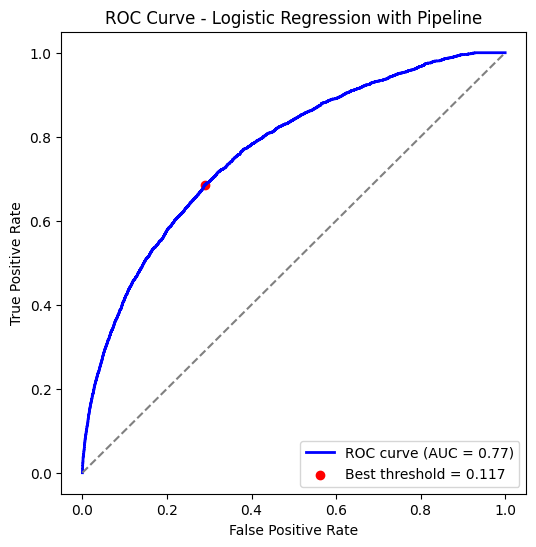

0.20455521


In [150]:


# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = roc_auc_score(y_test, y_score)
J = tpr - fpr
ix = J.argmax()
best_thresh = thresholds[ix]

print(f"Best Threshold = {best_thresh:.3f}, Sensitivity = {tpr[ix]:.3f}, Specificity = {1-fpr[ix]:.3f}")

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], color="gray", linestyle="--")
plt.scatter(fpr[ix], tpr[ix], marker="o", color="red", label=f"Best threshold = {best_thresh:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression with Pipeline")
plt.legend(loc="lower right")
plt.show()
precision, recall, thresholds = precision_recall_curve(y_test, y_score)
f1_scores = 2*precision*recall/(precision+recall)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]
print(best_threshold)

In [151]:
y_pred = (y_score >= 0.19).astype(int)

# Evaluate
print("accuracy_score = ",round(accuracy_score(y_test,y_pred)*100,2),"%",sep="")
print("precision_score = ",round(precision_score(y_test,y_pred)*100,2),"%",sep="")
print("recall_score = ",round(recall_score(y_test,y_pred)*100,2),"%",sep="")
print("f1_score = ",round(f1_score(y_test,y_pred)*100,2),"%",sep="")

accuracy_score = 81.68%
precision_score = 31.99%
recall_score = 48.65%
f1_score = 38.6%


Best Threshold = 0.205
Precision = 0.339, Recall = 0.456, F1 = 0.389


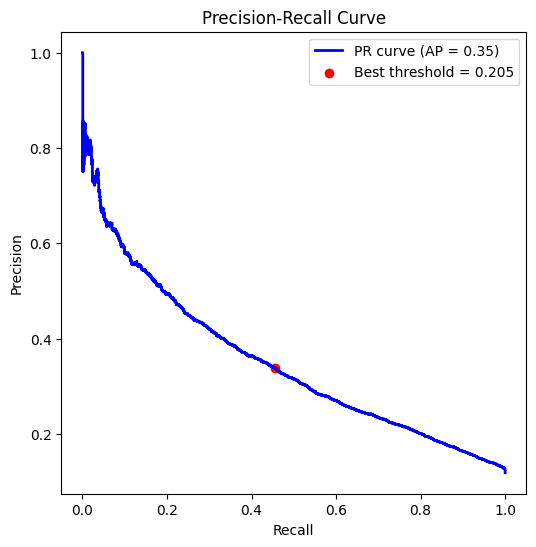

In [152]:
precision, recall, thresholds = precision_recall_curve(y_test, y_score)
avg_prec = average_precision_score(y_test, y_score)

# Compute F1 for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
ix = f1_scores.argmax()
best_thresh = thresholds[ix]

print(f"Best Threshold = {best_thresh:.3f}")
print(f"Precision = {precision[ix]:.3f}, Recall = {recall[ix]:.3f}, F1 = {f1_scores[ix]:.3f}")

# Plot PRC
plt.figure(figsize=(6,6))
plt.plot(recall, precision, color="blue", lw=2, label=f"PR curve (AP = {avg_prec:.2f})")
plt.scatter(recall[ix], precision[ix], marker="o", color="red", 
            label=f"Best threshold = {best_thresh:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="upper right")
plt.show()

In [153]:
y_pred = (y_score >= best_thresh).astype(int)

# Evaluate
print("accuracy_score = ",round(accuracy_score(y_test,y_pred)*100,2),"%",sep="")
print("precision_score = ",round(precision_score(y_test,y_pred)*100,2),"%",sep="")
print("recall_score = ",round(recall_score(y_test,y_pred)*100,2),"%",sep="")
print("f1_score = ",round(f1_score(y_test,y_pred)*100,2),"%",sep="")

accuracy_score = 83.02%
precision_score = 33.88%
recall_score = 45.58%
f1_score = 38.87%
